In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/movielenseda/ratings.csv")

df.rating = df.rating.astype(int)

df.head(5)

,userId,movieId,rating,timestamp
0,1,17,4,944249077
1,1,25,1,944250228
2,1,29,2,943230976
3,1,30,5,944249077
4,1,32,5,943228858


In [2]:
# Разделим на трейн и тест по 01.01.2018

train_df = df.loc[(df.timestamp < 1514764800)].copy()
test_df = df.loc[(df.timestamp >= 1514764800)].copy()

In [3]:
print(f"Тест и трейн разделены в соотношении примерно 1:{round(train_df.shape[0] / test_df.shape[0])}")

Тест и трейн разделены в соотношении примерно 1:3


In [4]:
train_users = train_df.userId.unique()
test_users = test_df.userId.unique()

# Возьмем только тех людей, которые попали и в трейн, и в тест
all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  8567
число людей всего: 165667


In [5]:
n_users = all_included.shape[0]

# В трейне и тесте выделим только тех, кто есть и там, и там
train_df = train_df.loc[train_df.userId.isin(all_included)].copy()
test_df = test_df.loc[test_df.userId.isin(all_included)].copy()

assert train_df.timestamp.max() < test_df.timestamp.min()
assert train_df.userId.nunique() == n_users
assert test_df.userId.nunique() == n_users

In [6]:
# Сгруппируем все интеракции по пользователям
train_grouped = train_df.groupby('userId').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.movieId, 
                                                 x.rating), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('userId').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.movieId,
                                                         x.rating), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

/tmp/ipykernel_47/1267106097.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_grouped = train_df.groupby('userId').apply(
/tmp/ipykernel_47/1267106097.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_grouped = test_df.groupby('userId').apply(


,userId,train_interactions
0,28,"[(8666, 0), (54, 1), (75, 1), (160, 1), (174, ..."
1,35,"[(1247, 2), (1590, 2), (1917, 2), (6365, 2), (..."
2,100,"[(49274, 1), (60069, 1), (34, 2), (1127, 2), (..."
3,111,"[(104, 2), (288, 2), (356, 2), (2424, 2), (316..."
4,140,"[(94959, 2), (168254, 2), (6870, 3), (56587, 3..."


In [7]:
joined = train_grouped.merge(test_grouped)
joined

,userId,train_interactions,test_interactions
0,28,"[(8666, 0), (54, 1), (75, 1), (160, 1), (174, ...","[(4125, 0), (4138, 0), (261759, 1), (5679, 2),..."
1,35,"[(1247, 2), (1590, 2), (1917, 2), (6365, 2), (...","[(2513, 2), (5218, 2), (5618, 2), (7115, 2), (..."
2,100,"[(49274, 1), (60069, 1), (34, 2), (1127, 2), (...","[(8533, 1), (222477, 1), (608, 2), (1183, 2), ..."
3,111,"[(104, 2), (288, 2), (356, 2), (2424, 2), (316...","[(168330, 3), (158238, 4)]"
4,140,"[(94959, 2), (168254, 2), (6870, 3), (56587, 3...","[(160954, 3), (176101, 5), (177593, 5), (17776..."
...,...,...,...
8562,200898,"[(4306, 3), (115713, 3), (122904, 3), (152081,...","[(2662, 2), (6534, 3), (78469, 3), (85414, 3),..."
8563,200915,"[(88267, 0), (18, 1), (592, 1), (1676, 1), (21...","[(60069, 5)]"
8564,200920,"[(159721, 0), (56949, 1), (63992, 1), (72407, ...","[(179819, 3), (122906, 4), (122912, 5)]"
8565,200930,"[(2706, 0), (4718, 0), (122904, 0), (171729, 0...","[(112556, 0), (140880, 0), (176149, 0), (92259..."


In [8]:
# Метрики для оценки ранжирования. Здесь мы работает с explicit feedback, поэтому не каждый айтем из теста понравился пользователю.
# Для упрощения буду считать, что релевантными айтемами в тесте для пользователя оказались те, которым он поставил оценку 3 и выше

def ndcg_metric(gt_items, predicted, k=10):
    # Обрезаем по k
    predicted = predicted[:k]

    # 1, если релеванта, 0 - если нет
    relevance = np.array([1 if x in gt_items else 0 for x in predicted])

    rank_dcg = dcg(relevance)
    if rank_dcg == 0:
        return 0.0

    # Идеальная реливантность - когда все реливантные айтемы в начале
    ideal_relevance = np.sort(relevance)[::-1]
    ideal_dcg = dcg(ideal_relevance)
    if ideal_dcg == 0:
        return 0.0

    return rank_dcg / ideal_dcg


def dcg(scores):
    # Дисконтируем кумулятивную сумму
    ranks = np.arange(1, len(scores) + 1)
    return np.sum((2 ** scores - 1) / np.log2(ranks + 1))

def recall_metric(gt_items, predicted, k=10):
    # Количество релевантный айтемов
    predicted = predicted[:k]
    n_gt = len(gt_items)
    # Ищем пересечение предсказанных релевантный и релевантныйх
    intersection = len(set(gt_items).intersection(set(predicted)))
    # Ищем долю
    return intersection / n_gt

def evaluate_recommender(df, model_preds, gt_col='test_interactions', k=10):
    # Функция для подсчета обоих метрик по датафрейму
    
    metric_values = []
    
    for _, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        # pred_items = row[model_preds][:k]
        pred_items = row[model_preds]
        
        metric_values.append((
            ndcg_metric(gt_items, pred_items, k=k),
            recall_metric(gt_items, pred_items, k=k)
        ))
        
    return {
        'ndcg': np.mean([x[0] for x in metric_values]),
        'recall': np.mean([x[1] for x in metric_values])
    }

Сначала попробуем наивные подходы. 1 - будем случайным образом рекомендовать пользователям фильмы.

In [9]:
class Random:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):
        # Получаем список всех айтемов
        items = set()
        for _, row in df.iterrows():
            for item, _ in row[col]:
                items.add(item)

        self.items = list(items)
        self.trained = True

    def predict(self, df, topn=100):
        random_lst = []
        # Случайным образом достаем рекомендации из списка айтемов
        for _ in range(len(df)):
            random_lst.append(list(np.random.choice(self.items, replace=False, size=topn)))

        return pd.Series(random_lst)


random = Random()
random.fit(joined)

joined['random_recs'] = random.predict(joined, topn=5)
joined.head()  

,userId,train_interactions,test_interactions,random_recs
0,28,"[(8666, 0), (54, 1), (75, 1), (160, 1), (174, ...","[(4125, 0), (4138, 0), (261759, 1), (5679, 2),...","[167130, 5866, 8042, 174677, 104936]"
1,35,"[(1247, 2), (1590, 2), (1917, 2), (6365, 2), (...","[(2513, 2), (5218, 2), (5618, 2), (7115, 2), (...","[49079, 75446, 6434, 180321, 134280]"
2,100,"[(49274, 1), (60069, 1), (34, 2), (1127, 2), (...","[(8533, 1), (222477, 1), (608, 2), (1183, 2), ...","[100647, 107141, 131516, 123034, 80729]"
3,111,"[(104, 2), (288, 2), (356, 2), (2424, 2), (316...","[(168330, 3), (158238, 4)]","[41569, 4919, 137563, 7234, 106967]"
4,140,"[(94959, 2), (168254, 2), (6870, 3), (56587, 3...","[(160954, 3), (176101, 5), (177593, 5), (17776...","[78157, 93336, 53282, 88280, 79494]"


In [10]:
# Получаем очень слабый результат
evaluate_recommender(joined, model_preds='random_recs', k=5)
# {'ndcg': 0.006320572864107364, 'recall': 0.0001924525380061611}

{'ndcg': 0.005915809522757906, 'recall': 5.5479802784530693e-05}

In [11]:
# Попробуем всем рекомендовать наиболее полпулярные айтемы
class TopPopular:

    def __init__(self):

        self.trained = False
    
    def fit(self, df, col='train_interactions'):
        # Получаем словарь всех фильмов с количеством их оценок
        counts = {}
        for _, row in df.iterrows():
            for item, _ in row[col]:
                if item in counts:
                    counts[item] += 1
                else:
                    counts[item] = 1
        # Сортируем словарь по значениям            
        counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
        # Записываем фильмы по убыванию популярности в self.recomendations
        self.recommenations = [x[0] for x in counts]
        self.trained = True
        return self.recommenations
        
    def predict(self, df, topn=100)  -> list[np.ndarray]:
        # Рекомендуем заданное topn число популярных фильмов
        assert self.trained
        return [self.recommenations[:topn]]*len(df)

    
toppop = TopPopular()
most_pop = toppop.fit(joined)

joined['toppopular_recs'] = toppop.predict(joined, topn=50)
joined.head() 

,userId,train_interactions,test_interactions,random_recs,toppopular_recs
0,28,"[(8666, 0), (54, 1), (75, 1), (160, 1), (174, ...","[(4125, 0), (4138, 0), (261759, 1), (5679, 2),...","[167130, 5866, 8042, 174677, 104936]","[2571, 79132, 2959, 318, 356, 4993, 296, 58559..."
1,35,"[(1247, 2), (1590, 2), (1917, 2), (6365, 2), (...","[(2513, 2), (5218, 2), (5618, 2), (7115, 2), (...","[49079, 75446, 6434, 180321, 134280]","[2571, 79132, 2959, 318, 356, 4993, 296, 58559..."
2,100,"[(49274, 1), (60069, 1), (34, 2), (1127, 2), (...","[(8533, 1), (222477, 1), (608, 2), (1183, 2), ...","[100647, 107141, 131516, 123034, 80729]","[2571, 79132, 2959, 318, 356, 4993, 296, 58559..."
3,111,"[(104, 2), (288, 2), (356, 2), (2424, 2), (316...","[(168330, 3), (158238, 4)]","[41569, 4919, 137563, 7234, 106967]","[2571, 79132, 2959, 318, 356, 4993, 296, 58559..."
4,140,"[(94959, 2), (168254, 2), (6870, 3), (56587, 3...","[(160954, 3), (176101, 5), (177593, 5), (17776...","[78157, 93336, 53282, 88280, 79494]","[2571, 79132, 2959, 318, 356, 4993, 296, 58559..."


In [12]:
evaluate_recommender(joined, model_preds='toppopular_recs', k=50)

{'ndcg': 0.26859844443705844, 'recall': 0.06326940267766082}

Результат улучшился значительно, но люди редко смотрят фильмы по нескольку раз, нужно убрать из рекомендаций те фильмы, которые пользователь уже оценивал

In [13]:
# Будем фильтровать рекомендации, удалим те фильмы, которые пользователь уже оценил
class ModifiedTopPopular(TopPopular):

    def __init__(self):

        self.trained = False

        
    def predict(self, df, topn=100)  -> list[np.ndarray]:
        
        assert self.trained
        
        all_recs = []
        
        for idx, row in df.iterrows():
            
            user_recs = []
            
            user_interactions = set([x[0] for x in row['train_interactions']])

            # Добавляем в рекомендации только те фильмы, которые пользователь еще не смотрел
            for elem in self.recommenations:
                if elem not in user_interactions:
                    user_recs.append(elem)
                    
                if len(user_recs) == topn:
                    break
                    
            all_recs.append(user_recs)
                
        return all_recs

    
toppop = ModifiedTopPopular()
toppop.fit(joined)
joined['toppopular_recs_filtered'] = toppop.predict(joined, topn=50)
joined.head()

,userId,train_interactions,test_interactions,random_recs,toppopular_recs,toppopular_recs_filtered
0,28,"[(8666, 0), (54, 1), (75, 1), (160, 1), (174, ...","[(4125, 0), (4138, 0), (261759, 1), (5679, 2),...","[167130, 5866, 8042, 174677, 104936]","[2571, 79132, 2959, 318, 356, 4993, 296, 58559...","[74458, 8368, 1258, 111759, 98809, 48385, 9225..."
1,35,"[(1247, 2), (1590, 2), (1917, 2), (6365, 2), (...","[(2513, 2), (5218, 2), (5618, 2), (7115, 2), (...","[49079, 75446, 6434, 180321, 134280]","[2571, 79132, 2959, 318, 356, 4993, 296, 58559...","[60069, 1198, 1682, 68954, 68157, 59315, 1, 33..."
2,100,"[(49274, 1), (60069, 1), (34, 2), (1127, 2), (...","[(8533, 1), (222477, 1), (608, 2), (1183, 2), ...","[100647, 107141, 131516, 123034, 80729]","[2571, 79132, 2959, 318, 356, 4993, 296, 58559...","[2571, 2959, 296, 6874, 1682, 858, 68157, 3379..."
3,111,"[(104, 2), (288, 2), (356, 2), (2424, 2), (316...","[(168330, 3), (158238, 4)]","[41569, 4919, 137563, 7234, 106967]","[2571, 79132, 2959, 318, 356, 4993, 296, 58559...","[2571, 4993, 296, 58559, 7153, 5952, 260, 1196..."
4,140,"[(94959, 2), (168254, 2), (6870, 3), (56587, 3...","[(160954, 3), (176101, 5), (177593, 5), (17776...","[78157, 93336, 53282, 88280, 79494]","[2571, 79132, 2959, 318, 356, 4993, 296, 58559...","[2571, 296, 58559, 593, 4226, 4306, 72998, 653..."


In [14]:
evaluate_recommender(joined, model_preds='toppopular_recs_filtered', k=50)

{'ndcg': 0.43753388229868534, 'recall': 0.10796040415133244}

Результат стал еще лучше, попробуем его улучшить использую метод SLIM (Sparse Linear Methods), но чтобы не обучать 41 тысяч моделей линейно регрессии (по одной на каждый айтем), оставим только 5000 - 1000 - 500 - 100 наиболее популярных

In [15]:
def make_pop_df(df, n):
    train_df_pop = df[df["movieId"].isin(most_pop[:n])].copy()
    return(train_df_pop)

In [16]:
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder

def make_matrix(df):
    # Есть пропуски в movieId и userId, поэтому необходимо использовать LabelEncoder
    user_enc = LabelEncoder()
    item_enc = LabelEncoder()
    
    df["user_idx"] = user_enc.fit_transform(df["userId"])
    df["item_idx"] = item_enc.fit_transform(df["movieId"])
    
    # Для экономии оперативной памяти для разреженной user-item матрицы, используем csr_matrix из scipy
    M = csr_matrix(
        (df["rating"], (df["user_idx"], df["item_idx"])),
        shape=(df["user_idx"].max() + 1, df["item_idx"].max() + 1)
    )
    return (M, user_enc, item_enc)

In [17]:
from joblib import Parallel, delayed
from sklearn.linear_model import ElasticNet

def fit_SLIM(M):
    # Будем обучать ElasticNet для каждого айтема, зададим параметры
    alpha = 0.01 # регуляризация
    l1_ratio = 0.1 # L1/L2 смешение
    n_jobs = -1 # -1 = использовать все ядра процессора
    n_items = M.shape[1]
    
    # Матрица весов
    W = np.zeros((n_items, n_items), dtype=np.float32)
    
    # Преобразуем матрицу к LIL один раз
    M_lil = M.tolil()
    
    def train_item(i):
        # Целевая переменная
        y = M.getcol(i).toarray().ravel()
    
        # Будем обучать только по пользователям, где y > 0
        mask = y > 0
        if mask.sum() < 2:  # Нет связи — пропускаем
            return i, np.zeros(n_items)
    
        # Готовим X
        X = M_lil.copy()
        X[:, i] = 0
        X = X.tocsr()
    
        # Обучаем модель
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, positive=True, fit_intercept=False)
        model.fit(X[mask], y[mask])
    
        # Вырезаем self-вес
        coef = model.coef_
        coef[i] = 0
    
        return i, coef
    
    # Запускаем параллельно
    results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(train_item)(i) for i in range(n_items)
    )
    
    # Заполняем матрицу весов
    for i, coef in results:
        W[i] = coef
    
    print("Обучение завершено")
    
    return W

In [18]:
def recommend(user_id, user_enc, item_enc, N=50, M=1):
    # Преобразуем реальный user_id в индекс
    user_idx = user_enc.transform([user_id])[0]

    user_vector = predicted_scores[user_idx].ravel()
    seen_items = M.getrow(user_idx).indices
    user_vector[seen_items] = -np.inf

    # Получаем топ-N item_idx
    top_items_idx = np.argsort(user_vector)[-N:][::-1]
    
    # Декодируем обратно в оригинальные movieId
    return item_enc.inverse_transform(top_items_idx)

In [19]:
SLIM_recs = []

for n in [100 ,500, 1000, 5000]:

    data = make_pop_df(train_df, n)
    print(data.shape)

    matrix, user_encx, item_encx = make_matrix(data)
    print(matrix.shape)
    
    W = fit_SLIM(matrix)
    
    # Для получения предсказаний необходимо умножить исходную матрицу user-item на матрицу весов
    predicted_scores = matrix @ W  # матричное умножение
    
    pop_users = data.userId.unique()
    
    joined_pop = joined[joined.userId.isin(pop_users)]
    
    # Порекомендуем каждому 50 фильмов
    joined_pop["SLIM"] = joined_pop["userId"].apply(lambda x: recommend(x, user_encx, item_encx, N=50, M=matrix))

    SLIM_recs.append((n, evaluate_recommender(joined_pop, model_preds='SLIM', k=50)))
    print("Обучена")

(414371, 4)
(8433, 100)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   12.2s finished


Обучение завершено


/tmp/ipykernel_47/309194245.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joined_pop["SLIM"] = joined_pop["userId"].apply(lambda x: recommend(x, user_encx, item_encx, N=50, M=matrix))


Обучена
(1292869, 4)
(8502, 500)


...

Обучена
(3200152, 4)
(8565, 5000)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   21.7s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:  3.3min
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9.589770690524006, tolerance: 0.8496
  model = cd_fast.sparse_enet_coordinate_descent(
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:  6.2min
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:  9.2min
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.877010236555137, tolerance: 0.2452
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.11/dist-pa

Обучение завершено


/tmp/ipykernel_47/309194245.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joined_pop["SLIM"] = joined_pop["userId"].apply(lambda x: recommend(x, user_encx, item_encx, N=50, M=matrix))


Обучена


In [20]:
# {'ndcg': 0.4664269607552083, 'recall': 0.17677686601097384} на 

for res in SLIM_recs:
    print(f"SLIM{res[0]}: \n nDCG={round(res[1]['ndcg'], 5)}; \n Recall={round(res[1]['recall'], 5)}.")
    print("---"*10)

SLIM100: 
 nDCG=0.43944; 
 Recall=0.09279.
------------------------------
SLIM500: 
 nDCG=0.45982; 
 Recall=0.11777.
------------------------------
SLIM1000: 
 nDCG=0.45573; 
 Recall=0.11546.
------------------------------
SLIM5000: 
 nDCG=0.32865; 
 Recall=0.05268.
------------------------------


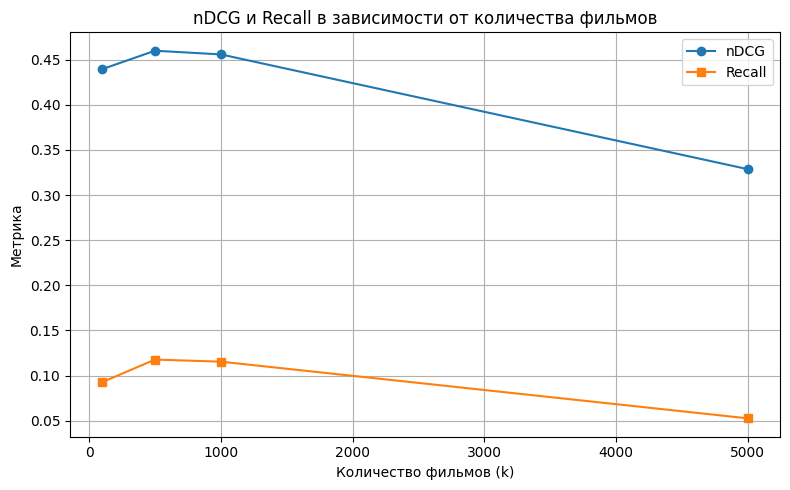

In [21]:
import matplotlib.pyplot as plt

# Построим визуализацию
k_values = [res[0] for res in SLIM_recs]
ndcg_values = [res[1]["ndcg"] for res in SLIM_recs]
recall_values = [res[1]["recall"] for res in SLIM_recs]

plt.figure(figsize=(8, 5))

plt.plot(k_values, ndcg_values, marker='o', label='nDCG')
plt.plot(k_values, recall_values, marker='s', label='Recall')

plt.xlabel("Количество фильмов (k)")
plt.ylabel("Метрика")
plt.title("nDCG и Recall в зависимости от количества фильмов")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Результат не плохой, но модель очень тяжелая и требовательная к ресурсам, попробуем EASE.

**Построим EASE**

In [22]:
train_df_pop = train_df[train_df["movieId"].isin(most_pop[:10000])].copy()

In [23]:
user_enc = LabelEncoder()
item_enc = LabelEncoder()

train_df_pop["user_id_x"] = user_enc.fit_transform(train_df_pop["userId"])
train_df_pop["item_id_x"] = item_enc.fit_transform(train_df_pop["movieId"])

num_users = train_df_pop["user_id_x"].nunique()
num_items = train_df_pop["item_id_x"].nunique()

train_df_pop.sample(5)

,userId,movieId,rating,timestamp,user_id_x,item_id_x
18387496,115148,113348,4,1446174774,4940,8904
14879621,93211,34542,4,1205204161,3970,5916
15131291,94784,72605,2,1371821625,4038,7410
30974036,194454,3000,2,1345738115,8298,2075
2920590,18398,6373,2,1421105959,749,4151


In [24]:
import scipy.sparse as sps

matrix = sps.coo_matrix(
    (np.ones(train_df_pop.shape[0]),
     (train_df_pop['user_id_x'], train_df_pop['item_id_x'])),
    shape=(num_users, num_items)
)

matrix

<COOrdinate sparse matrix of dtype 'float64'
	with 3493708 stored elements and shape (8567, 10000)>

In [25]:
def fit_ease(X, reg_weight=100):
    
    G = X.T @ X

    # L2-регуляризация: λI
    G += reg_weight * sps.identity(G.shape[0])

    # Преобразуем в dense
    G = G.todense()

    # Обратная матрица
    P = np.linalg.inv(G)

    # Формула EASE
    B = P / (-np.diag(P))

    # Нулевая диагональ
    np.fill_diagonal(B, 0.)

    return B

w = fit_ease(matrix)

In [26]:
w.shape

(10000, 10000)

In [27]:
def get_preds(x, item_enc, w):

    # Извлекаем movieId из кортежей
    user_items = [t[0] for t in x]

    # Оставляем только товары, которые были в обучении
    known_items = [t for t in user_items if t in item_enc.classes_]

    if len(known_items) == 0:
        return []  # если пользователь ничего не смотрел из обученного набора

    # Кодируем itemId
    encoded = item_enc.transform(known_items)

    # Создаём вектор взаимодействий
    vector = np.zeros(w.shape[0])
    vector[encoded] = 1
    vector = sps.csr_matrix(vector)

    # Предсказания
    preds = np.array(vector.dot(w))[0]

    # Не рекомендуем просмотренные товары
    preds[encoded] = -np.inf

    # ТОП-100 рекомендаций
    ranks = np.argsort(-preds)[:100]

    # Декодируем обратно item_idx
    decoded = item_enc.inverse_transform(ranks)

    return decoded

joined['ease_preds'] = joined.train_interactions.apply(
    lambda x: get_preds(x, item_enc, w)
)

In [28]:
evaluate_recommender(joined, model_preds='ease_preds', k=50)

{'ndcg': 0.4735306995376048, 'recall': 0.11446156849073208}

In [29]:
for col in ["random_recs", "toppopular_recs", "toppopular_recs_filtered", "ease_preds"]:
    result = evaluate_recommender(joined, model_preds=col, k=50)
    print(f"{col}: \n nDCG={round(result['ndcg'], 5)}; \n Recall={round(result['recall'], 5)}.")
    print("---"*10)

for res in SLIM_recs:
    print(f"SLIM{res[0]}: \n nDCG={round(res[1]['ndcg'], 5)}; \n Recall={round(res[1]['recall'], 5)}.")
    print("---"*10)

random_recs: 
 nDCG=0.00592; 
 Recall=6e-05.
------------------------------
toppopular_recs: 
 nDCG=0.2686; 
 Recall=0.06327.
------------------------------
toppopular_recs_filtered: 
 nDCG=0.43753; 
 Recall=0.10796.
------------------------------
ease_preds: 
 nDCG=0.47353; 
 Recall=0.11446.
------------------------------
SLIM100: 
 nDCG=0.43944; 
 Recall=0.09279.
------------------------------
SLIM500: 
 nDCG=0.45982; 
 Recall=0.11777.
------------------------------
SLIM1000: 
 nDCG=0.45573; 
 Recall=0.11546.
------------------------------
SLIM5000: 
 nDCG=0.32865; 
 Recall=0.05268.
------------------------------


**Общий вывод**
В ходе выполнения данного этапа данные были разделены на test и train методом Temporal split, когда данные делятся по определенной дате, здесь я взял дату 01.01.2018 так, чтобы она разделила данные в соотношении 3 к 1. Для корректности дальнейших испытаний, я оставил только тех пользователей, которые встречаются и в трейне, и в тесте.

Для оценки качества моделей были выбраны и написаны следующие метрики - Recall@k и nDCG@k. Recall позволяет оценить полноту полученных рекомендаций, долю айтемов из тех, что человек посмотрел в тесте от тех, что модель порекомендовала, а nDCG показывает правильность ранжирования рекомендаций, так, что чем выше релевантный объект рекомендует модель, тем выше его вес в оценке метрики.

1. Далее были построены наивные модели: случайные рекомендации и рекомендации популярных фильмов. Как и ожидалось, модель получила очень низкие оценки и Recall и nDCG - 0.00008 и 0.00591 соответсвенно. Это говорит о том, что модель совершенно не интересна для дальнейшего использования.
2. Следующая модель - рекомендовать популярные фильмы. Эта модель получила уже результат лучше - Recall=0.06327, nDCG=0.2686. Это модель подтвержает то, что люди часто смотрят именно популярные фильмы. Но у этой модели есть недостатки, она может рекомедовать фильмы, которые пользователь уже посмотрел, а это чаще всего не релевантно.
3. Дальнейшее улучшение - это добавление к модели рекомендаций популярных фильтрации по просмотренным фильмам. То есть она больше не будет рекомедовать то, что человек уже увидел. Это существенно улучшило метрики: Recall=0.43753 и Recall=0.11446.
4. В качестве следующей модели была выбрала SLIM. В ходе ее построения на каждый айтем обучается модель линейной регрессии, показывающая близость его к другим айтемам. Полученные веса записываются в матрицу. Данная модель оказалась очень затратной к ресурсам, и при обучении на всех айтемах могла занять около 5 часов, поэтому было принято решение ограничивать пул айтемов по популярности и передавать в модель только часть 100-500-1000-5000. Результаты отражены на графике. Оказалось что лучший результат достигается при ограничении списка 500 фильмов - Recall=0.11777, nDCG=0.45982.
5. Так как модель оказалось тяжелой, следующей была выбрана EASE, это очень легкая модель, имеющая решение в явном виде, и поэтому не требующая больших ресурсов. Однако ее результаты оказались даже лучше - Recall=0.11446, nDCG=0.47353.

Таким образом, для дальшейшего использования является наиболее предпочтительной модель EASE за свою легкость и неплохие показатели. Хотя, конечно, мы по прежднему рекомендуем в среднем 1 из 10 релевантных фильмов из тестовой выборки, что требует дальнейших улучшений.